In [1]:
from util import *

### Load Data

In [2]:
enrollment_df = load_enrollment()
gdp_df = load_gdp()

In loading these, I performed some very simple string cleaning (see util.py), but didn't do much else. I lightly checked for missing values, but based on the schema description I assumed that no data imputing was required. Specifically, _students5_estimated_ says:
>Estimated enrolment data this variable includes raw, interpolated, or extrapolated values and in addition to that, fills in an estimated value for institutions that never reported any enrolment data (see section on Treatment of Missing Data)

So I am assuming I do not need to perform any further imputatoin.

### Exploratory Data Analysis

In [3]:
# university count by region, country, then year
urc_y = enrollment_df.groupby(['year', 'region']).agg({'iau_id1': 'count', 'students5_estimated': ['min', q1, 'median', q3, 'max']}).sort_values(['year', 'region'])
urc_y

iau_id1 students5_estimated           \
                                      count                 min       q1   
year   region                                                              
1950.0 east asia and pacific           1131                 5.0   378.00   
       europe and central asia         1775                 2.0   377.50   
       latin america and caribbean      298                21.0   335.00   
       middle east and north africa      75                 6.0    85.50   
       north america                   1152                 0.0   472.25   
...                                     ...                 ...      ...   
2020.0 latin america and caribbean     2901                82.0  3626.00   
       middle east and north africa    1109                17.0  2030.00   
       north america                   1621                 3.0  1326.50   
       south asia                      1153                86.0  2107.00   
       sub-saharan africa              1319                59.0  1443.00   

                                                                 
                                     median       q3        max  
year   region                                                    
1950.0 east asia and pacific         1022.0  2488.00    52420.0  
       europe and central asia       1278.0  3159.50    64798.0  
       latin america and caribbean    883.0  2125.00    60675.0  
       middle east and north africa   312.5   975.75    16114.0  
       north america                 1307.0  4317.50    42861.0  
...                                     ...      ...        ...  
2020.0 latin america and caribbean   5948.0  8222.50   422444.0  
       middle east and north africa  4000.0  8945.00  1210557.0  
       north america                 3373.0  9840.50   101358.0  
       south asia                    3178.0  7269.00  2222857.0  
       sub-saharan africa            3082.0  6565.00   383530.0  

[105 rows x 6 columns]

### Observations

There is a large range (very high maxes). Data are spaced such that short-term events may be difficult to spot without interpolation, which would be presumptive since the data are not smooth. Events that line up to 5 year intervals should be visible.

In [4]:
# What's up with these huge max values?
enrollment_df.sort_values('students5_estimated', ascending=False).groupby(['region']).head(2)

,country,countrycode,region,incomegroup,iau_id,iau_id1,eng_name,orig_name,foundedyr,yrclosed,...,divisions,total_fields,unique_fields,specialized,merger,noiau,year,students5_interpolated,students5_extrapolated,students5_estimated
96,china,chn,east asia and pacific,upper middle income,glue-166,glue-166-1,the open university of china,NaN,1979.0,NaN,...,NaN,NaN,NaN,0.0,0.0,1.0,2020.0,2673333.0,2673333.0,2673333.0
95,china,chn,east asia and pacific,upper middle income,glue-166,glue-166-1,the open university of china,NaN,1979.0,NaN,...,NaN,NaN,NaN,0.0,0.0,1.0,2015.0,2566666.0,2566666.0,2566666.0
45261,india,ind,south asia,lower middle income,iau-007811,iau-007811-1,indira gandhi national open university,indira gandhi rashtriya mukta vishwavidyalaya ...,1985.0,NaN,...,21.0,47.0,45.0,0.0,0.0,0.0,2020.0,2222857.0,2222857.0,2222857.0
20459,iran,irn,middle east and north africa,upper middle income,iau-003534,iau-003534-1,islamic azad university,daneshgahe azad-e-islami (iau),1982.0,NaN,...,7.0,97.0,95.0,0.0,0.0,0.0,2020.0,1210557.0,1210557.0,1210557.0
4403,turkey,tur,europe and central asia,upper middle income,iau-000948,iau-000948-2,anadolu university,anadolu niversitesi,1958.0,NaN,...,16.0,68.0,61.0,0.0,1.0,0.0,2020.0,1122547.0,1122547.0,1122547.0
20458,iran,irn,middle east and north africa,upper middle income,iau-003534,iau-003534-1,islamic azad university,daneshgahe azad-e-islami (iau),1982.0,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,2015.0,1058333.0,1058333.0,1058333.0
4402,turkey,tur,europe and central asia,upper middle income,iau-000948,iau-000948-2,anadolu university,anadolu niversitesi,1958.0,NaN,...,NaN,NaN,NaN,0.0,1.0,0.0,2015.0,937446.0,937446.0,937446.0
4459,india,ind,south asia,lower middle income,iau-000955,iau-000955-1,andhra university,andhra university,1926.0,NaN,...,5.0,67.0,65.0,0.0,1.0,0.0,2020.0,881785.0,881785.0,881785.0
117832,brazil,bra,latin america and caribbean,upper middle income,iau-018601,iau-018601-1,estcio de s university,universidade estcio de s (unesa),1970.0,NaN,...,40.0,66.0,54.0,0.0,0.0,0.0,2020.0,422444.0,422444.0,422444.0
136336,south africa,zaf,sub-saharan africa,upper middle income,iau-020493,iau-020493-1,university of south africa,university of south africa - universiteit van ...,1873.0,NaN,...,9.0,213.0,190.0,0.0,0.0,0.0,2020.0,383530.0,383530.0,383530.0


Unsurprisingly, these are especially large universities in countries that have large-ish populations. Interesting, that some not-so-large population countries are on this list (South Africa and Argentina). Do those countries have fewer universities (ergo high density at each)?

In [5]:
# how many unique universities do these two countries have?
enrollment_df.groupby(['country']).agg({'iau_id1': 'nunique'}).sort_values('iau_id1', ascending=False).loc[['south africa', 'argentina']]

,iau_id1
country,
south africa,61
argentina,115


### Hypothesis

We should be able to spot the economic downturn around 2010. Let's ignore the max values and just plot the minimum to q3, since a 2,000,000+ enrollment university will make a plot useless.

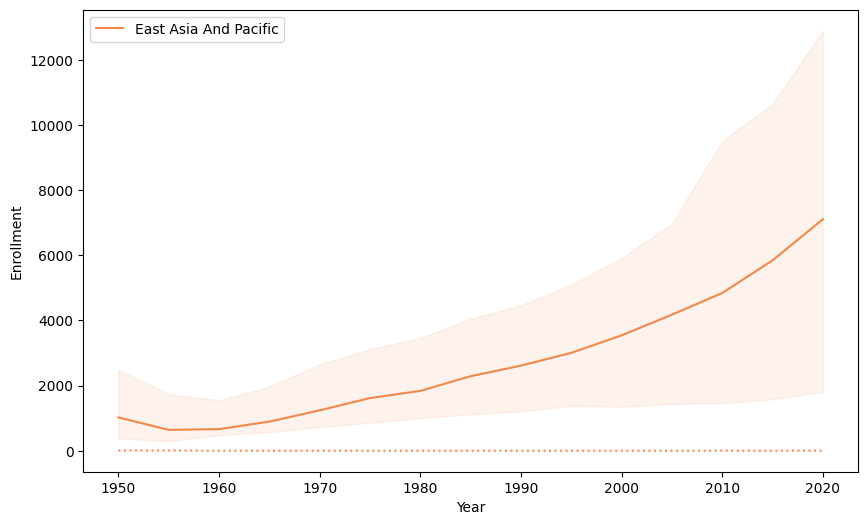

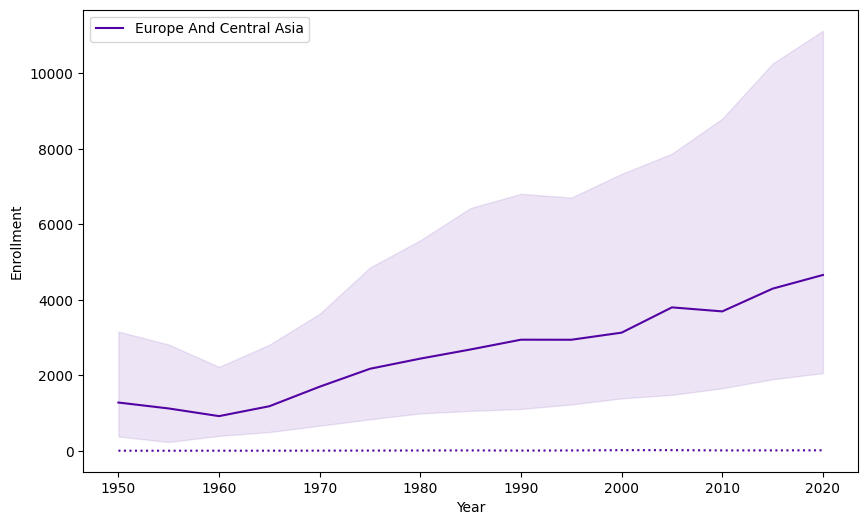

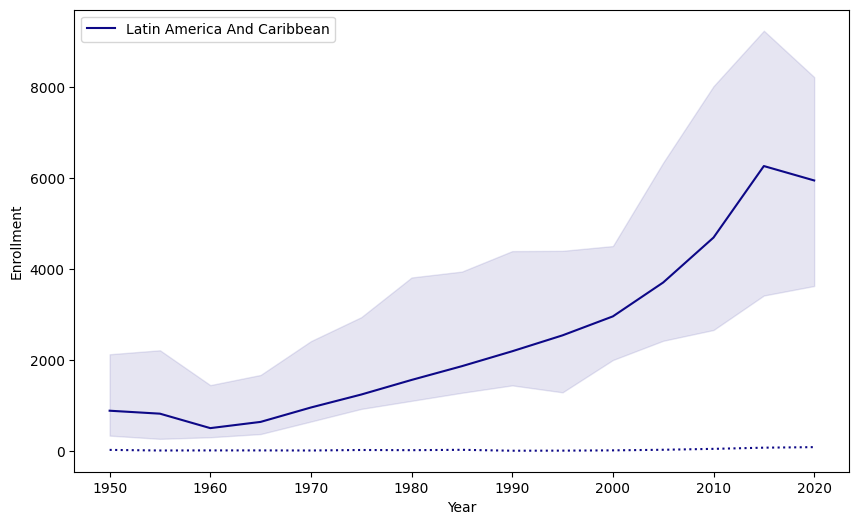

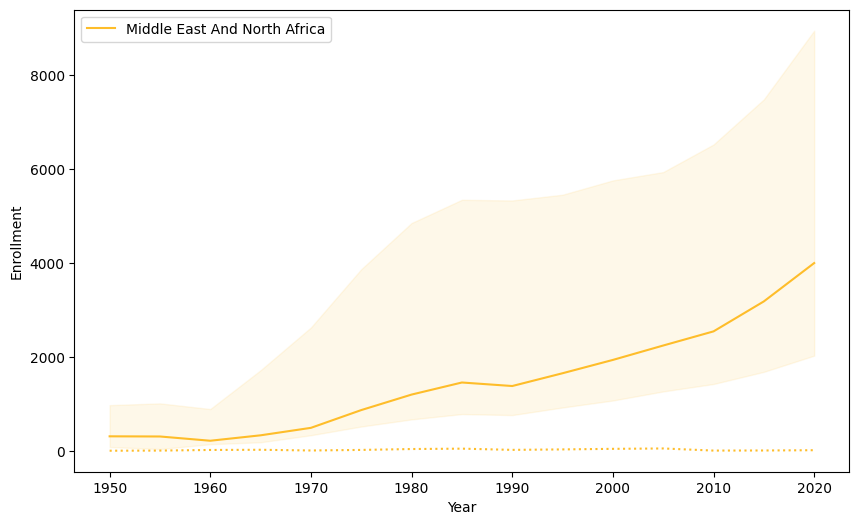

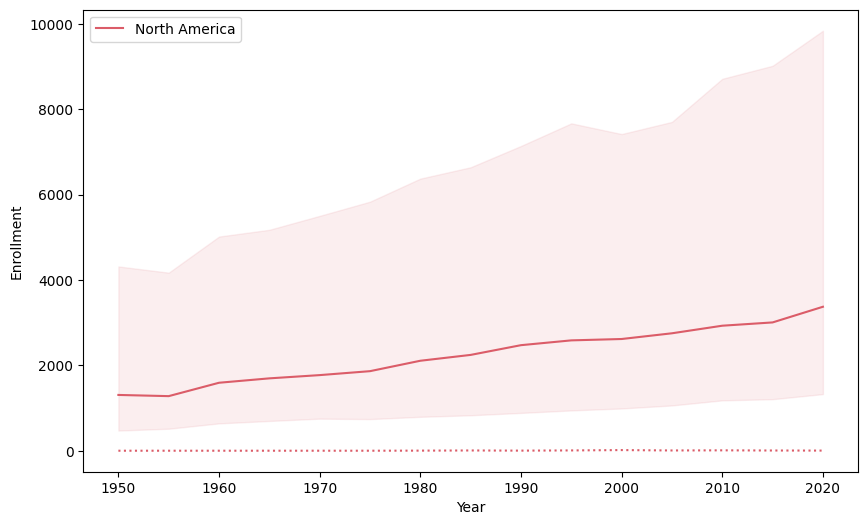

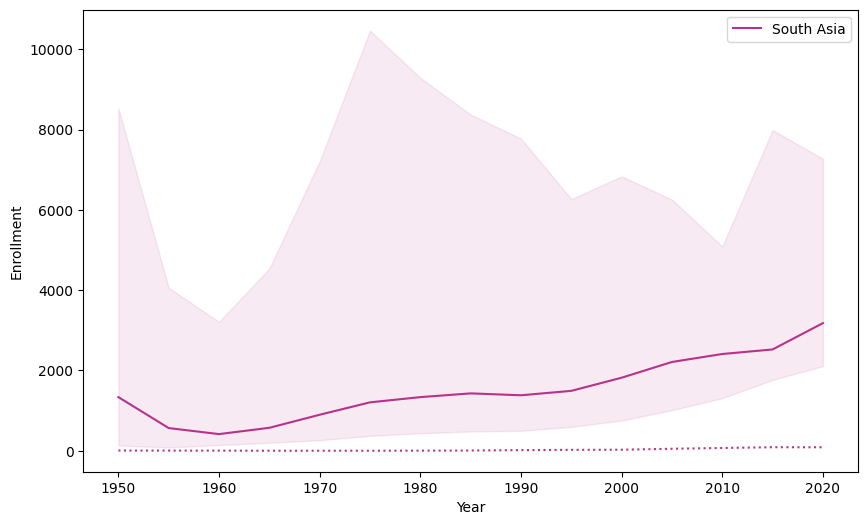

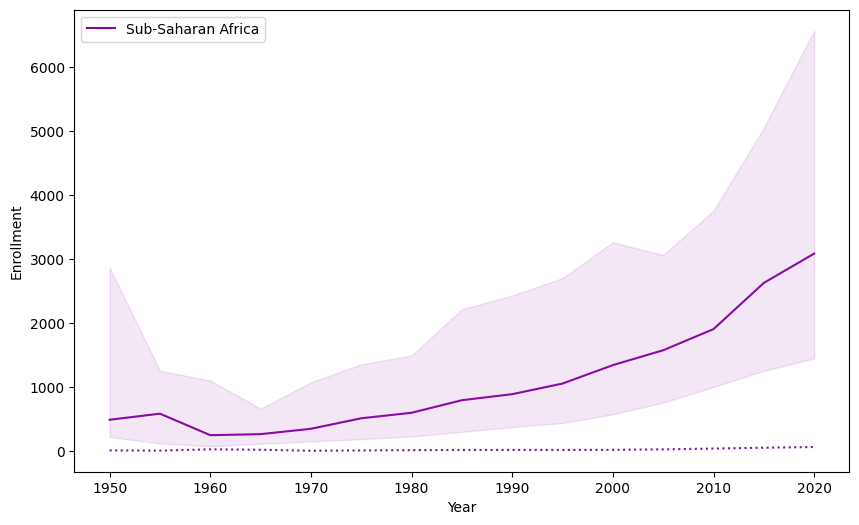

In [22]:
import matplotlib.pyplot as plt
from matplotlib import colormaps

cmap = colormaps.get_cmap('plasma')

filtered_df = enrollment_df.loc[~enrollment_df['region'].isna()]
regions = filtered_df['region'].unique()
n_r = len(regions)

color_map = {
    name: cmap(i / (n_r)) # only using n_r -1 colors, but the last will be low-contrast yellow
    for i, name in enumerate(regions)
}

filtered_df = filtered_df \
                .groupby(['region', 'year']) \
                .agg({'students5_estimated': ['min', q1, 'median', q3, 'max']}) \
                .reset_index(col_level=1)

filtered_df.columns = filtered_df.columns.droplevel(level=0)

for region, data in filtered_df.groupby('region'):
    fig, ax = plt.subplots(figsize=(10, 6))
    x = data['year']
    
    y_min, y_q1, y_med, y_q3, y_max = data['min'], data['q1'], data['median'], data['q3'], data['max']
    
    ax.plot(x, y_min, linestyle=':', color=color_map[region])
    ax.fill_between(x, y_q1, y_q3, alpha=0.1, color=color_map[region])
    ax.plot(x, y_med, color=color_map[region], label=region.title())

    ax.set_xlabel('Year')
    ax.set_ylabel('Enrollment')
    ax.legend()            
plt.show()

Visually, trends seem to align for most regions, although there are a significant deviations in enrollment in two places: the mid 2010's in Latin America and the Caribbean, and the mid 1970's in South Asia. East Asia and the Pacific seems to have a positive second derivative with accelerating growth; likely a function of population and gdp growth.

Not much evidence of change around 2010, though. Conventional wisdom is labor flees to education when labor market are difficult, but it's not obviously reflected here at the gross scale.

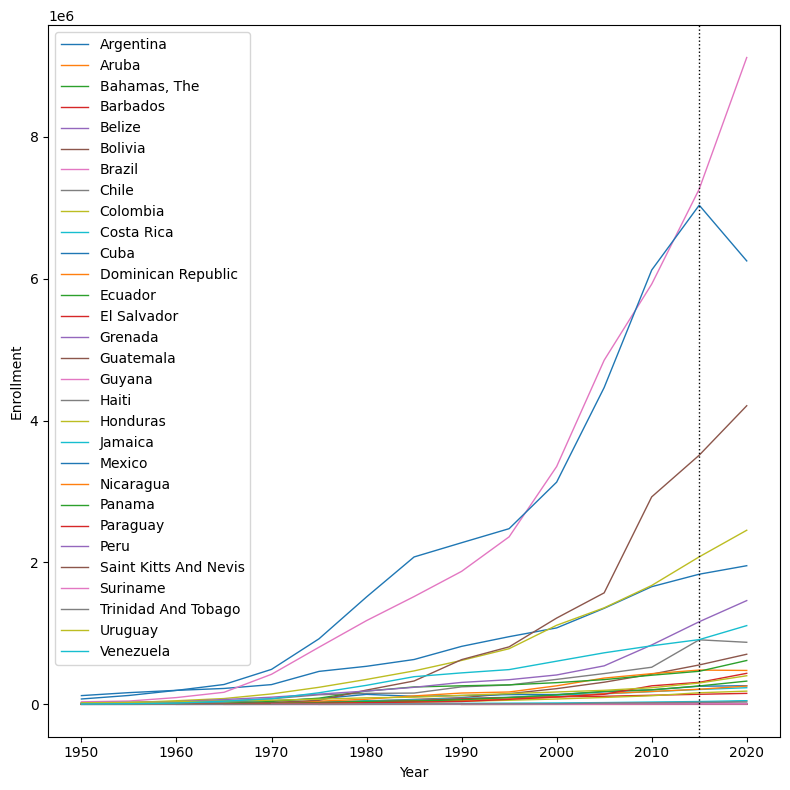

In [23]:
fig, ax = plt.subplots(figsize=(8, 8))

latinx_countries = enrollment_df.loc[enrollment_df['region'] == 'latin america and caribbean']

for country, data in latinx_countries.groupby('country'):
    r_df = data.groupby('year')['students5_estimated'].sum().reset_index()
    
    x, y = r_df['year'], r_df['students5_estimated']
           
    ax.plot(x, y, linewidth=1, label=country.title())
    
    ax.set_xlabel('Year')
    ax.set_ylabel('Enrollment')
ax.axvline(x=2015, color='black', linewidth=1, linestyle=':') # reference line
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

That was unexpected. Looks like exponential growth in Brazil and Mexico, although a drop after 2015 in Mexico (COVID-19 related?). I'm not sure what is driving the growth in Brazil, but after 1990 their enrollments began to climb at an accelerating rate. This graph doesn't perfectly align to the regional graph above, because that was looking at the range of enrollments of all universities by nation, and this is look at total national enrollment by nation. Technically measuring related but different things. In this case, the gross national enrollment is climbing, but the per-university enrollment saw the blip around 2015. That would imply the number of universities dropped (merged or closed?)


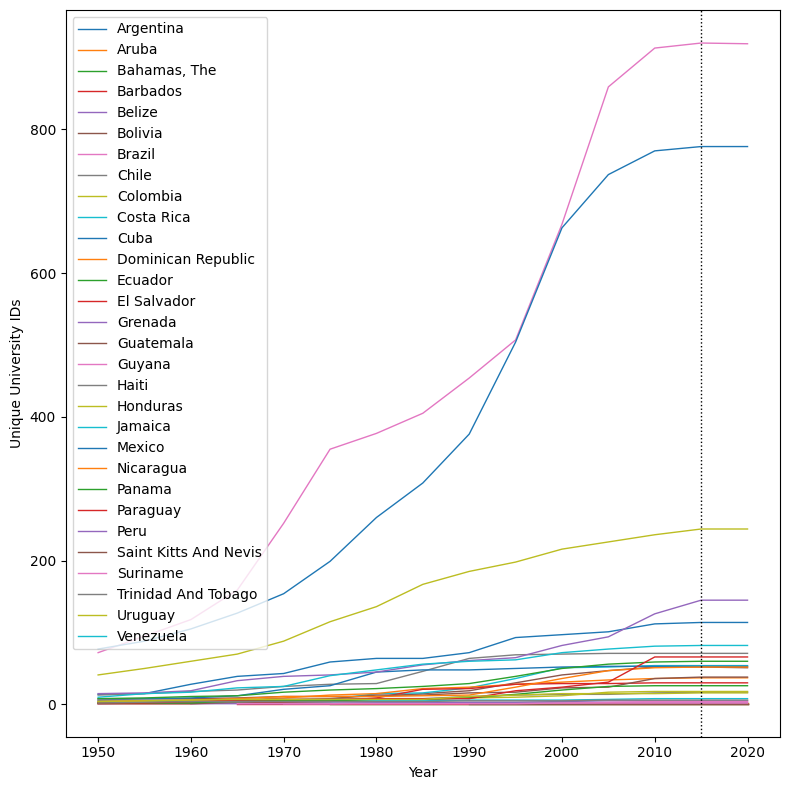

In [24]:
fig, ax = plt.subplots(figsize=(8, 8))

for country, data in latinx_countries.groupby('country'):
    r_df = data.groupby('year')['iau_id1'].nunique().reset_index()
    
    x, y = r_df['year'], r_df['iau_id1']
           
    ax.plot(x, y, linewidth=1, label=country.title())
    
    ax.set_xlabel('Year')
    ax.set_ylabel('Unique University IDs')
ax.axvline(x=2015, color='black', linewidth=1, linestyle=':') # reference line
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Hmm. It looks like the number of universities enrolling students leveled off in Brazil and Mexico, so it's possible that enrollment was simply trailing and returned to "typical" student density values slightly later.

---

What about South Asia in the 1970's?

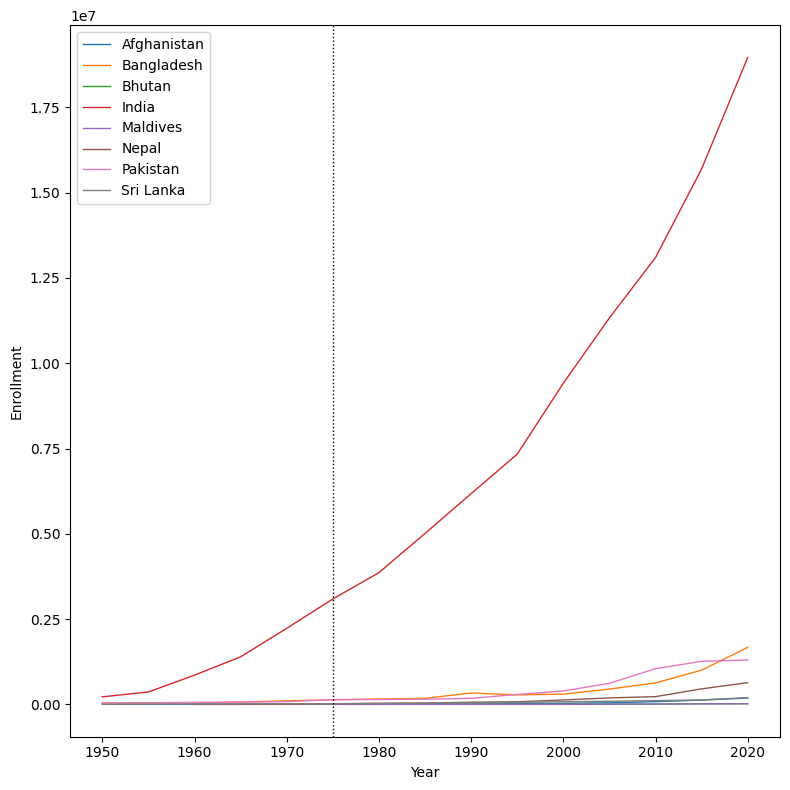

In [25]:
fig, ax = plt.subplots(figsize=(8, 8))

south_asian_countries = enrollment_df.loc[enrollment_df['region'] == 'south asia']

for country, data in south_asian_countries.groupby('country'):
    r_df = data.groupby('year')['students5_estimated'].sum().reset_index()
    
    x, y = r_df['year'], r_df['students5_estimated']
           
    ax.plot(x, y, linewidth=1, label=country.title())
    
    ax.set_xlabel('Year')
    ax.set_ylabel('Enrollment')
ax.axvline(x=1975, color='black', linewidth=1, linestyle=':') # reference line
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

As above, there's an accelerating growth in enrollment in India. This doesn't exactly explain why there is a relative rise in enrollment on a per-university basis in the 1970's; these two graphs would seem to imply that India added many universities in the 1970's. As above, this graph doesn't perfectly align for the same reasons. Did India found new universities after the mid 1970's?

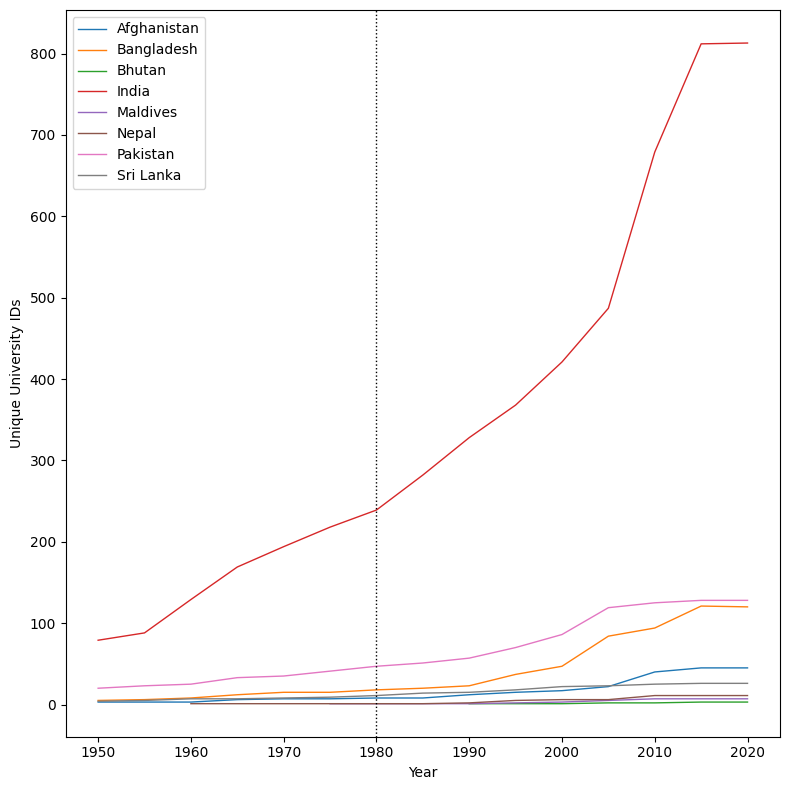

In [26]:
fig, ax = plt.subplots(figsize=(8, 8))

south_asian_countries = enrollment_df.loc[enrollment_df['region'] == 'south asia']

for country, data in south_asian_countries.groupby('country'):
    r_df = data.groupby('year')['iau_id1'].nunique().reset_index()
    
    x, y = r_df['year'], r_df['iau_id1']
           
    ax.plot(x, y, linewidth=1, label=country.title())
    
    ax.set_xlabel('Year')
    ax.set_ylabel('Unique University IDs')
ax.axvline(x=1980, color='black', linewidth=1, linestyle=':') # reference line
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

There's an increase in rate in about 1980, that might explain the blip. This would be an interesting thing to delve into deeper.

---

Above, I noticed that there doesn't seem to be a large difference in enrollment related to the Cold War or East/West divide. No spikes or drops in Europe and Central Asia, although that may be an issue of grouping western and eastern Europe together.

What if we look at just the NATO and Warsaw Pact countries? Let's use the total number of enrollees (sum of all institutions).

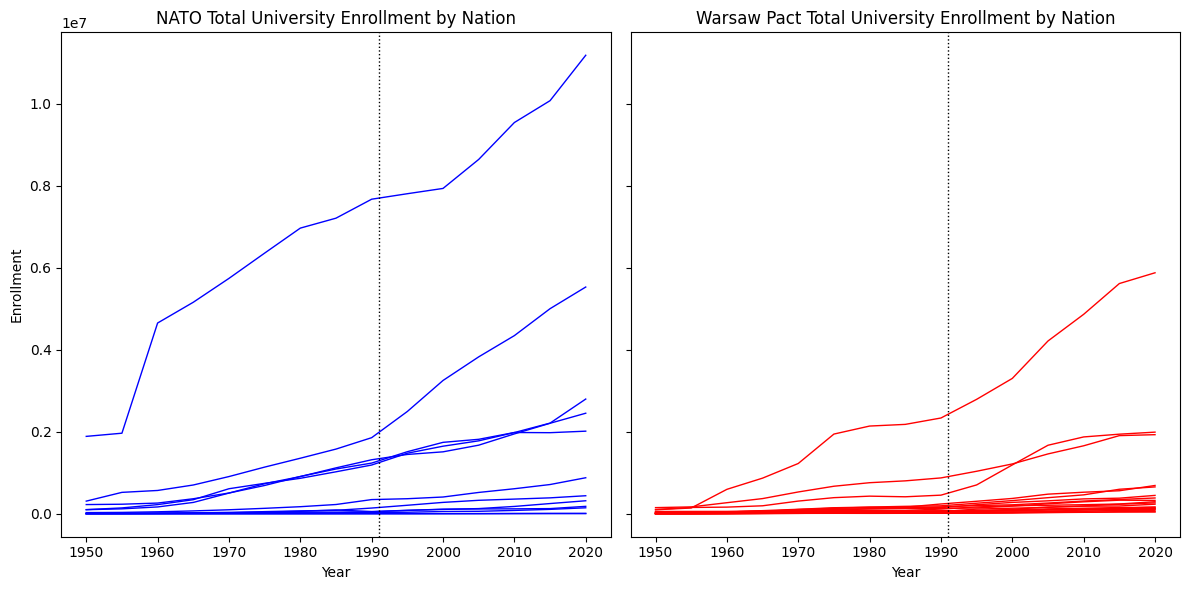

In [27]:
from itertools import chain


NATO_founders = ['belgium', 'canada', 'denmark', 'france', 'iceland', 'italy', 'luxembourg', 'netherlands', 'norway', 'portugal', 'united kingdom', 'united states'] # just the founding nations, for simplicity
 # USSR creates some challenges; ignoring balkanization, just focus on the extant soviet republics at the time
Warsaw_Pact = ['albania', 'bulgaria', 'czech republic', 'hungary', 'poland', 'romania', 'russian federation', 'armenia', 'belarus', 'estonia', 'georgia', 'kazakhstan', 'kyrgyz republic', 'latvia', 'lithuania', 'moldova', 'tajikistan', 'turkmenistan', 'ukraine', 'uzbekistan']

fig, axs = plt.subplots(ncols=2, figsize=(12, 6), sharex=True, sharey=True)
for c in chain(NATO_founders, Warsaw_Pact):
    r_df = enrollment_df.loc[(enrollment_df['country'] == c)] \
            .groupby('year')['students5_estimated'].sum().reset_index()
    
    x, y = r_df['year'], r_df['students5_estimated']
           
    axs[0 if (which:=c in NATO_founders) else 1].plot(x, y, color='blue' if which else 'red', linewidth=1)

axs[0].set_xlabel('Year')
axs[0].set_ylabel('Enrollment')
axs[0].set_title('NATO Total University Enrollment by Nation')

axs[0].axvline(x=1991, linewidth=1, color='black', linestyle=':') # ussr breakup reference line

axs[1].set_xlabel('Year')
axs[1].set_title('Warsaw Pact Total University Enrollment by Nation')

axs[1].axvline(x=1991, linewidth=1, color='black', linestyle=':') # ussr breakup reference line

plt.tight_layout()
plt.show()

I don't really see much changing around 1991 and the breakup of the USSR, but the total enrollment is notably smaller in the Eastern Bloc than in NATO countries. One NATO country seems to be driving the trend (not labeled here, but I would bet dollars to donuts it's the United States). The Warsaw Pact countries seem to have modestly higher growth after the dissolution of the USSR. Interesting to note that one of the NATO founding countries sees a similar growth pattern, which was no expected.

One more hypothesis: one would assume that enrollment is related to breadth of programs. What if we plot enrollment as a function of total_fields? Presumably there is a positive association.

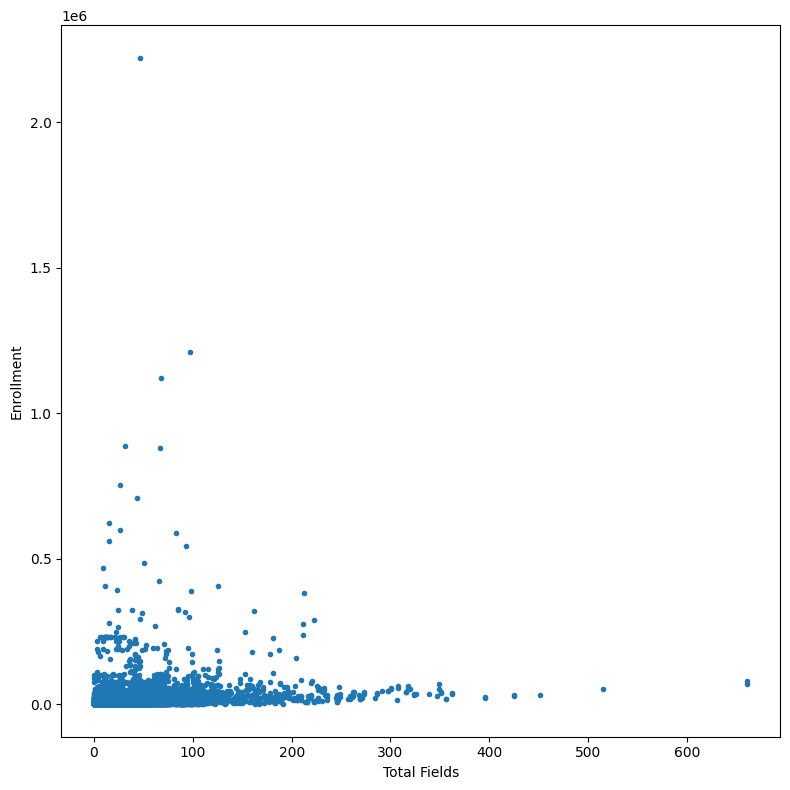

In [28]:
fig, ax = plt.subplots(figsize=(8, 8))

filtered_df = enrollment_df.dropna(subset=['students5_estimated', 'total_fields'])

x, y = filtered_df['total_fields'], filtered_df['students5_estimated']
           
ax.scatter(x, y, marker='.')
    
ax.set_xlabel('Total Fields')
ax.set_ylabel('Enrollment')
plt.tight_layout()
plt.show()

Hardly a clear association. Definitely not linear, but probably monotonic. However, there are some _wild_ outliers here. Let's look at those quickly. The very high enrollment with modest number of fields is almost certainly the open university in china, which we saw above. But who is offering over 600 unique degree programs?

In [29]:
enrollment_df.loc[enrollment_df['total_fields'] > 390].sort_values('total_fields', ascending=False)[['year', 'country', 'eng_name', 'total_fields', 'unique_fields', 'students5_estimated']]

,year,country,eng_name,total_fields,unique_fields,students5_estimated
137352,2015.0,canada,university of toronto,661.0,257.0,78713.0
137350,2020.0,canada,university of toronto,661.0,257.0,70028.0
138267,2020.0,czech republic,charles university in prague,515.0,255.0,51884.0
16403,2020.0,"korea, rep",chonnam national university,451.0,207.0,33195.0
133862,2015.0,canada,university of manitoba,425.0,201.0,29557.0
133863,2020.0,canada,university of manitoba,425.0,201.0,30683.0
136181,2015.0,canada,university of saskatchewan,396.0,171.0,21450.0
136182,2020.0,canada,university of saskatchewan,396.0,171.0,24345.0


Interesting. Looks like the University of Toronto offers multiple degrees in numerous fields.